# REST EEG Connectivity Analysis

静息态脑电数据的连接性分析
- 计算PLI连接性矩阵 (5个频段)
- 计算小世界网络指标
- 生成可视化和统计结果

**分析需求:**
- 组水平描述性分析 + 与行为/临床数据相关分析
- 全部5个频段: delta, theta, alpha, beta, gamma
- 保留全矩阵(加权网络)
- 静态分析为主

## 1. 导入库和配置参数

In [6]:
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings

import numpy as np
import pandas as pd
import mne
from mne_connectivity import spectral_connectivity_epochs
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
from tqdm.notebook import tqdm  # notebook版本的进度条

# 忽略MNE的一些警告
warnings.filterwarnings('ignore', category=RuntimeWarning)

# 设置matplotlib中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print(f"MNE版本: {mne.__version__}")
print(f"NumPy版本: {np.__version__}")

MNE版本: 1.8.0
NumPy版本: 1.23.5


In [7]:
# =============================================================================
# 配置参数 - 根据需要修改
# =============================================================================

# 数据路径
DATA_PATH = Path(r'd:\LYW\REST_COM\preprocessing\data\6epoch_clean')
OUTPUT_PATH = Path(r'd:\LYW\REST_COM\connectivity_analysis')
RESULTS_PATH = OUTPUT_PATH / 'results'
FIGURES_PATH = OUTPUT_PATH / 'figures'

# 创建输出目录
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# 被试ID列表
SUB_IDS = ['001', '021', '022', '024', '047', '049', '051', '071', '072', '073', '076', '092']

# 采样率
SFREQ = 500

# 频段定义
FREQ_BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45)
}

# 连接性计算参数
CONNECTIVITY_METHOD = 'pli'  # Phase Lag Index
N_JOBS = 4  # 并行作业数，根据您的CPU核心数调整

# 随机网络基线参数
NUM_RANDOM_GRAPHS = 50

print("配置完成!")
print(f"数据路径: {DATA_PATH}")
print(f"输出路径: {OUTPUT_PATH}")
print(f"被试数量: {len(SUB_IDS)}")
print(f"频段数量: {len(FREQ_BANDS)}")

配置完成!
数据路径: d:\LYW\REST_COM\preprocessing\data\6epoch_clean
输出路径: d:\LYW\REST_COM\connectivity_analysis
被试数量: 12
频段数量: 5


## 2. 数据加载与验证

In [8]:
# 数据对齐参数 (参考频域分析)
TARGET_SFREQ = 500  # 目标采样率
TARGET_DURATION = 10.0  # 目标epoch时长（秒）
TARGET_SAMPLES = int(TARGET_SFREQ * TARGET_DURATION)  # 5000 采样点

def load_epochs(sub_id: str, data_path: Path = DATA_PATH) -> Optional[mne.Epochs]:
    """
    加载单个被试的epoch数据，并进行数据对齐
    
    数据对齐步骤:
    1. 检查采样率，如果不是500Hz则重采样
    2. 统一epoch长度到5000采样点（10秒 × 500Hz）
    """
    fif_path = data_path / f'{sub_id}-epo.fif'
    if not fif_path.exists():
        print(f"警告: 文件不存在 - {fif_path}")
        return None
    
    try:
        epochs = mne.read_epochs(fif_path, preload=True, verbose=False)
        
        # 1. 检查采样率，如果不是500Hz则重采样
        if epochs.info['sfreq'] != TARGET_SFREQ:
            print(f"  [{sub_id}] 重采样: {epochs.info['sfreq']} -> {TARGET_SFREQ} Hz")
            epochs = epochs.resample(TARGET_SFREQ)
        
        # 2. 统一epoch长度：截取到目标采样点数
        n_times = len(epochs.times)
        if n_times != TARGET_SAMPLES:
            # 计算需要的tmax，确保得到exactly TARGET_SAMPLES个点
            tmax = (TARGET_SAMPLES - 1) / TARGET_SFREQ
            epochs = epochs.crop(tmin=0, tmax=tmax)
            print(f"  [{sub_id}] 统一epoch长度: {n_times} -> {len(epochs.times)} 采样点")
        
        return epochs
    except Exception as e:
        print(f"加载失败 {sub_id}: {e}")
        return None


def load_all_subjects(sub_ids: List[str] = SUB_IDS) -> Dict[str, mne.Epochs]:
    """加载所有被试的epoch数据并进行数据对齐"""
    epochs_dict = {}
    
    print("加载被试数据并进行对齐...")
    print(f"目标: {TARGET_SFREQ} Hz, {TARGET_DURATION}秒 ({TARGET_SAMPLES} 采样点)")
    print("-" * 60)
    
    for sub_id in tqdm(sub_ids, desc="加载进度"):
        epochs = load_epochs(sub_id)
        if epochs is not None:
            epochs_dict[sub_id] = epochs
    
    print(f"\n{'='*60}")
    print(f"成功加载 {len(epochs_dict)}/{len(sub_ids)} 个被试")
    print(f"所有数据已对齐到: {TARGET_SFREQ} Hz, {TARGET_SAMPLES} 采样点")
    print(f"{'='*60}")
    return epochs_dict

In [9]:
# 加载所有被试数据
epochs_dict = load_all_subjects()

加载被试数据并进行对齐...
目标: 500 Hz, 10.0秒 (5000 采样点)
------------------------------------------------------------


加载进度:   0%|          | 0/12 [00:00<?, ?it/s]

  [001] 重采样: 1000.0 -> 500 Hz
  [021] 重采样: 1000.0 -> 500 Hz
  [022] 统一epoch长度: 5001 -> 5000 采样点
  [024] 统一epoch长度: 5001 -> 5000 采样点
  [047] 重采样: 1000.0 -> 500 Hz
  [049] 重采样: 1000.0 -> 500 Hz
  [051] 统一epoch长度: 5001 -> 5000 采样点
  [071] 统一epoch长度: 5001 -> 5000 采样点
  [072] 重采样: 1000.0 -> 500 Hz
  [073] 重采样: 1000.0 -> 500 Hz
  [076] 统一epoch长度: 5001 -> 5000 采样点
  [092] 重采样: 1000.0 -> 500 Hz

成功加载 12/12 个被试
所有数据已对齐到: 500 Hz, 5000 采样点


In [10]:
def validate_data(epochs_dict: Dict[str, mne.Epochs]) -> pd.DataFrame:
    """验证数据完整性并返回数据概要"""
    summary = []
    
    for sub_id, epochs in epochs_dict.items():
        info = {
            'subject_id': sub_id,
            'n_epochs': len(epochs),
            'n_channels': len(epochs.ch_names),
            'sfreq': epochs.info['sfreq'],
            'n_times': len(epochs.times),
            'tmin': epochs.tmin,
            'tmax': epochs.tmax,
            'duration': epochs.tmax - epochs.tmin
        }
        summary.append(info)
    
    df = pd.DataFrame(summary)
    return df

# 验证数据
data_summary = validate_data(epochs_dict)
print("\n数据验证摘要:")
display(data_summary)

# 检查数据一致性
print("\n数据一致性检查:")
print(f"  采样率统一: {data_summary['sfreq'].nunique() == 1} (目标: {TARGET_SFREQ} Hz)")
print(f"  采样点数统一: {data_summary['n_times'].nunique() == 1} (目标: {TARGET_SAMPLES} 点)")
print(f"  通道数统一: {data_summary['n_channels'].nunique() == 1}")

if data_summary['sfreq'].nunique() > 1:
    print(f"\n  ⚠️  警告: 检测到不同采样率: {data_summary['sfreq'].unique()}")
if data_summary['n_times'].nunique() > 1:
    print(f"\n  ⚠️  警告: 检测到不同采样点数: {data_summary['n_times'].unique()}")

# 保存数据摘要
data_summary.to_csv(RESULTS_PATH / 'data_summary.csv', index=False)
print(f"\n✓ 数据摘要已保存: {RESULTS_PATH / 'data_summary.csv'}")


数据验证摘要:


,subject_id,n_epochs,n_channels,sfreq,n_times,tmin,tmax,duration
0,001,25,60,500.0,5000,0.0,9.998,9.998
1,021,32,60,500.0,5000,0.0,9.998,9.998
2,022,22,60,500.0,5000,0.0,9.998,9.998
3,024,25,60,500.0,5000,0.0,9.998,9.998
4,047,18,60,500.0,5000,0.0,9.998,9.998
5,049,23,60,500.0,5000,0.0,9.998,9.998
6,051,29,60,500.0,5000,0.0,9.998,9.998
7,071,33,60,500.0,5000,0.0,9.998,9.998
8,072,25,60,500.0,5000,0.0,9.998,9.998
9,073,28,60,500.0,5000,0.0,9.998,9.998



数据一致性检查:
  采样率统一: True (目标: 500 Hz)
  采样点数统一: True (目标: 5000 点)
  通道数统一: True

✓ 数据摘要已保存: d:\LYW\REST_COM\connectivity_analysis\results\data_summary.csv


In [11]:
# 查看样例数据的通道信息
sample_sub = list(epochs_dict.keys())[0]
sample_epochs = epochs_dict[sample_sub]

print(f"样例被试: {sample_sub}")
print(f"通道数: {len(sample_epochs.ch_names)}")
print(f"通道名称: {sample_epochs.ch_names}")
print(f"\nEpoch信息:")
print(sample_epochs)

样例被试: 001
通道数: 60
通道名称: ['Fp1', 'F3', 'F7', 'F9', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'C4', 'Cz', 'FC2', 'FC6', 'F8', 'F4', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'FCz', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'F2', 'AF4', 'AF8']

Epoch信息:
<EpochsFIF | 25 events (all good), 0 – 9.998 s (baseline off), ~57.3 MiB, data loaded,
 '1': 25>


## 3. 连接性矩阵计算

In [12]:
def compute_connectivity_matrix(
    epochs: mne.Epochs,
    fmin: float,
    fmax: float,
    method: str = CONNECTIVITY_METHOD,
    n_jobs: int = N_JOBS
) -> np.ndarray:
    """
    计算单个被试单个频段的连接性矩阵
    
    Parameters
    ----------
    epochs : mne.Epochs
        Epoch数据
    fmin, fmax : float
        频率范围
    method : str
        连接性计算方法
    n_jobs : int
        并行作业数
        
    Returns
    -------
    adj_matrix : np.ndarray
        对称的邻接矩阵 (n_channels, n_channels)
    """
    con = spectral_connectivity_epochs(
        epochs,
        method=method,
        mode='multitaper',
        sfreq=epochs.info['sfreq'],
        fmin=fmin,
        fmax=fmax,
        faverage=True,
        mt_adaptive=False,
        n_jobs=n_jobs,
        verbose=False
    )
    
    # 获取连接性矩阵
    mat = con.get_data(output='dense')[:, :, 0]
    
    # 对称化 (PLI本身应该是对称的,但确保一下)
    adj_matrix = mat + mat.T - np.diag(mat.diagonal())
    
    return adj_matrix

测试被试: 001
测试频段: alpha (8-13 Hz)

连接性矩阵形状: (60, 60)
连接性值范围: [0.0000, 0.5906]
平均连接强度: 0.2646


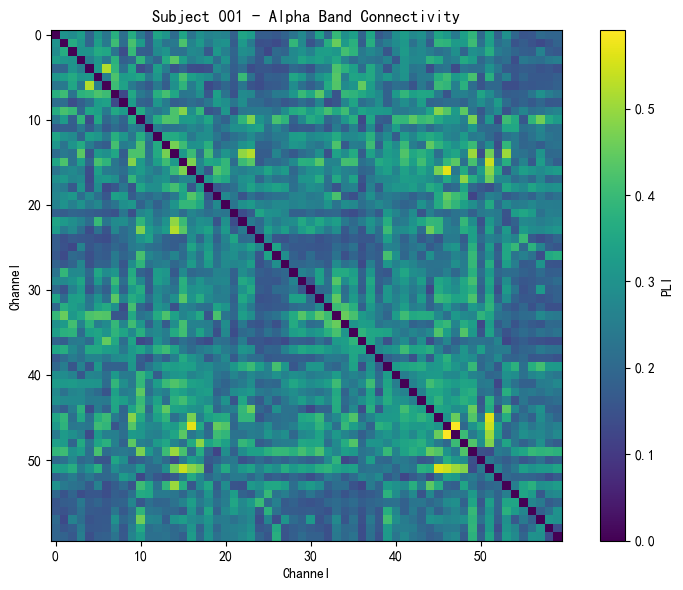

In [13]:
# 测试：计算单个被试单个频段的连接性
test_sub = list(epochs_dict.keys())[0]
test_epochs = epochs_dict[test_sub]

print(f"测试被试: {test_sub}")
print(f"测试频段: alpha (8-13 Hz)")

test_adj = compute_connectivity_matrix(test_epochs, fmin=8, fmax=13)

print(f"\n连接性矩阵形状: {test_adj.shape}")
print(f"连接性值范围: [{test_adj.min():.4f}, {test_adj.max():.4f}]")
print(f"平均连接强度: {np.mean(test_adj[np.triu_indices_from(test_adj, k=1)]):.4f}")

# 可视化测试结果
plt.figure(figsize=(8, 6))
plt.imshow(test_adj, cmap='viridis')
plt.colorbar(label='PLI')
plt.title(f'Subject {test_sub} - Alpha Band Connectivity')
plt.xlabel('Channel')
plt.ylabel('Channel')
plt.tight_layout()
plt.show()

In [ ]:
def compute_all_connectivity(
    epochs_dict: Dict[str, mne.Epochs],
    freq_bands: Dict[str, Tuple[float, float]] = FREQ_BANDS
) -> Dict[str, np.ndarray]:
    """
    计算所有被试所有频段的连接性矩阵
    
    Returns
    -------
    connectivity_data : dict
        {freq_band: array(n_subjects, n_channels, n_channels)}
    """
    sub_ids = list(epochs_dict.keys())
    n_subjects = len(sub_ids)
    
    # 获取通道数
    sample_epochs = list(epochs_dict.values())[0]
    n_channels = len(sample_epochs.ch_names)
    
    print("="*60)
    print("计算连接性矩阵...")
    print(f"被试数: {n_subjects}, 通道数: {n_channels}, 频段数: {len(freq_bands)}")
    print("="*60)
    
    connectivity_data = {}
    
    for band_name, (fmin, fmax) in freq_bands.items():
        print(f"\n频段: {band_name} ({fmin}-{fmax} Hz)")
        
        band_matrices = np.zeros((n_subjects, n_channels, n_channels))
        
        for i, sub_id in enumerate(tqdm(sub_ids, desc=f"  {band_name}")):
            epochs = epochs_dict[sub_id]
            adj = compute_connectivity_matrix(epochs, fmin, fmax)
            band_matrices[i] = adj
        
        connectivity_data[band_name] = band_matrices
    
    return connectivity_data

In [ ]:
# 计算所有连接性矩阵 (这一步可能需要10-20分钟)
connectivity_data = compute_all_connectivity(epochs_dict)

In [ ]:
# 保存连接性矩阵
sub_ids = list(epochs_dict.keys())
ch_names = list(epochs_dict.values())[0].ch_names

np.savez(
    RESULTS_PATH / 'connectivity_results.npz',
    **connectivity_data,
    subject_ids=sub_ids,
    channel_names=ch_names
)
print(f"连接性矩阵已保存: {RESULTS_PATH / 'connectivity_results.npz'}")

## 4. 小世界网络指标计算

In [ ]:
def precompute_random_baseline(
    n_nodes: int,
    n_edges: int,
    num_random: int = NUM_RANDOM_GRAPHS,
    seed: int = 42
) -> Tuple[float, float]:
    """
    预计算随机网络的基线指标
    
    Returns
    -------
    avg_clustering : float
        随机网络平均聚类系数
    avg_path_length : float  
        随机网络平均路径长度
    """
    rng = np.random.default_rng(seed)
    clustering_list = []
    path_length_list = []
    
    for _ in tqdm(range(num_random), desc="生成随机网络"):
        # 生成随机图
        G = nx.gnm_random_graph(n_nodes, n_edges, seed=int(rng.integers(1e9)))
        
        # 检查连通性
        if not nx.is_connected(G):
            continue
        
        # 分配随机权重
        for u, v in G.edges:
            G[u][v]['weight'] = rng.random()
        
        # 计算指标
        c = nx.average_clustering(G, weight='weight')
        l = nx.average_shortest_path_length(G, weight='weight')
        
        if c > 0 and l > 0:
            clustering_list.append(c)
            path_length_list.append(l)
    
    return np.mean(clustering_list), np.mean(path_length_list)

In [ ]:
def compute_small_world_metrics(
    adj_matrix: np.ndarray,
    c_rand: float,
    l_rand: float
) -> Dict[str, float]:
    """
    计算单个网络的小世界指标
    
    Returns
    -------
    metrics : dict
        包含 clustering, path_length, sigma, avg_connectivity
    """
    # 创建图
    G = nx.from_numpy_array(adj_matrix)
    
    # 聚类系数
    clustering = nx.average_clustering(G, weight='weight')
    
    # 特征路径长度
    if nx.is_connected(G):
        path_length = nx.average_shortest_path_length(G, weight='weight')
    else:
        # 取最大连通分量
        largest_cc = max(nx.connected_components(G), key=len)
        G_sub = G.subgraph(largest_cc)
        path_length = nx.average_shortest_path_length(G_sub, weight='weight')
    
    # 小世界系数
    sigma = (clustering / c_rand) / (path_length / l_rand) if c_rand > 0 and l_rand > 0 else np.nan
    
    # 平均连接强度
    avg_connectivity = np.mean(adj_matrix[np.triu_indices_from(adj_matrix, k=1)])
    
    return {
        'clustering': clustering,
        'path_length': path_length,
        'sigma': sigma,
        'avg_connectivity': avg_connectivity
    }

In [ ]:
# 获取网络参数
sample_matrix = list(connectivity_data.values())[0][0]
n_nodes = sample_matrix.shape[0]
n_edges = n_nodes * (n_nodes - 1) // 2

print(f"网络参数: {n_nodes} 节点, {n_edges} 边")
print(f"生成 {NUM_RANDOM_GRAPHS} 个随机网络基线...")

# 预计算随机基线
c_rand, l_rand = precompute_random_baseline(n_nodes, n_edges)
print(f"\n随机基线: C_rand={c_rand:.4f}, L_rand={l_rand:.4f}")

In [ ]:
def compute_all_small_world_metrics(
    connectivity_data: Dict[str, np.ndarray],
    sub_ids: List[str],
    c_rand: float,
    l_rand: float
) -> pd.DataFrame:
    """
    计算所有被试所有频段的小世界指标
    """
    print("\n" + "="*60)
    print("计算小世界网络指标...")
    print("="*60)
    
    results = []
    
    for band_name, matrices in connectivity_data.items():
        print(f"\n处理频段: {band_name}")
        
        for i, sub_id in enumerate(tqdm(sub_ids, desc=f"  {band_name}")):
            adj = matrices[i]
            metrics = compute_small_world_metrics(adj, c_rand, l_rand)
            
            results.append({
                'subject_id': sub_id,
                'freq_band': band_name,
                **metrics
            })
    
    return pd.DataFrame(results)

# 计算所有小世界指标
sub_ids = list(epochs_dict.keys())
metrics_df = compute_all_small_world_metrics(connectivity_data, sub_ids, c_rand, l_rand)

In [ ]:
# 查看结果
print("小世界指标结果:")
display(metrics_df)

# 保存结果
metrics_df.to_csv(RESULTS_PATH / 'small_world_metrics.csv', index=False)
print(f"\n小世界指标已保存: {RESULTS_PATH / 'small_world_metrics.csv'}")

## 5. 描述性统计

In [ ]:
def compute_descriptive_stats(metrics_df: pd.DataFrame) -> pd.DataFrame:
    """计算描述性统计"""
    stats = metrics_df.groupby('freq_band').agg({
        'clustering': ['mean', 'std', 'min', 'max'],
        'path_length': ['mean', 'std', 'min', 'max'],
        'sigma': ['mean', 'std', 'min', 'max'],
        'avg_connectivity': ['mean', 'std', 'min', 'max']
    }).round(4)
    
    return stats

# 计算描述性统计
desc_stats = compute_descriptive_stats(metrics_df)
print("描述性统计:")
display(desc_stats)

# 保存
desc_stats.to_csv(RESULTS_PATH / 'descriptive_stats.csv')
print(f"\n描述性统计已保存: {RESULTS_PATH / 'descriptive_stats.csv'}")

In [ ]:
def create_subject_level_summary(metrics_df: pd.DataFrame) -> pd.DataFrame:
    """创建被试级汇总数据 (宽格式, 便于与行为数据合并)"""
    # 转换为宽格式
    pivot_df = metrics_df.pivot(index='subject_id', columns='freq_band')
    
    # 扁平化列名
    pivot_df.columns = [f'{band}_{metric}' for metric, band in pivot_df.columns]
    pivot_df = pivot_df.reset_index()
    
    return pivot_df

# 创建被试级汇总
subject_summary = create_subject_level_summary(metrics_df)
print("被试级汇总 (可与行为数据合并):")
display(subject_summary)

# 保存
subject_summary.to_csv(RESULTS_PATH / 'subject_level_metrics.csv', index=False)
print(f"\n被试级汇总已保存: {RESULTS_PATH / 'subject_level_metrics.csv'}")

## 6. 可视化

In [ ]:
# 6.1 各频段组平均连接性热图
n_bands = len(connectivity_data)
fig, axes = plt.subplots(1, n_bands, figsize=(4 * n_bands, 4))

if n_bands == 1:
    axes = [axes]

for ax, (band_name, matrices) in zip(axes, connectivity_data.items()):
    # 组平均
    mean_matrix = np.mean(matrices, axis=0)
    
    # 绘制热图
    im = ax.imshow(mean_matrix, cmap='viridis', aspect='auto')
    ax.set_title(f'{band_name}\n({FREQ_BANDS[band_name][0]}-{FREQ_BANDS[band_name][1]} Hz)')
    ax.set_xlabel('Channel')
    ax.set_ylabel('Channel')
    plt.colorbar(im, ax=ax, label='PLI')

plt.tight_layout()
fig.savefig(FIGURES_PATH / 'connectivity_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"保存: {FIGURES_PATH / 'connectivity_heatmaps.png'}")

In [ ]:
# 6.2 网络指标箱线图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metric_names = ['clustering', 'path_length', 'sigma', 'avg_connectivity']
titles = ['Clustering Coefficient', 'Path Length', 'Small-world Coefficient (σ)', 'Average Connectivity']

for ax, metric, title in zip(axes.flat, metric_names, titles):
    sns.boxplot(data=metrics_df, x='freq_band', y=metric, ax=ax,
                order=['delta', 'theta', 'alpha', 'beta', 'gamma'])
    ax.set_title(title)
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel(metric)
    
    # 添加参考线 (小世界系数=1)
    if metric == 'sigma':
        ax.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='σ=1')
        ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_PATH / 'network_metrics_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"保存: {FIGURES_PATH / 'network_metrics_boxplot.png'}")

In [ ]:
# 6.3 Alpha频段个体连接性热图
band_name = 'alpha'
matrices = connectivity_data[band_name]
n_subjects = len(sub_ids)

n_cols = 4
n_rows = (n_subjects + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = axes.flatten()

vmin = np.min(matrices)
vmax = np.max(matrices)

for i, (sub_id, ax) in enumerate(zip(sub_ids, axes)):
    im = ax.imshow(matrices[i], cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Sub {sub_id}')
    ax.set_xticks([])
    ax.set_yticks([])

# 隐藏多余的子图
for j in range(len(sub_ids), len(axes)):
    axes[j].axis('off')

# 添加colorbar
fig.colorbar(im, ax=axes, shrink=0.6, label='PLI')
fig.suptitle(f'{band_name.capitalize()} Band Connectivity ({FREQ_BANDS[band_name][0]}-{FREQ_BANDS[band_name][1]} Hz)',
             fontsize=14)

plt.tight_layout()
fig.savefig(FIGURES_PATH / f'connectivity_individual_{band_name}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"保存: {FIGURES_PATH / f'connectivity_individual_{band_name}.png'}")

In [ ]:
# 6.4 各频段平均连接强度对比
fig, ax = plt.subplots(figsize=(10, 6))

band_order = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = plt.cm.viridis(np.linspace(0, 1, len(band_order)))

for i, band in enumerate(band_order):
    band_data = metrics_df[metrics_df['freq_band'] == band]['avg_connectivity']
    ax.scatter([i] * len(band_data), band_data, color=colors[i], alpha=0.6, s=50, label=band)
    ax.errorbar(i, band_data.mean(), yerr=band_data.std(), color='black', capsize=5, capthick=2, fmt='o', markersize=10)

ax.set_xticks(range(len(band_order)))
ax.set_xticklabels([f"{b}\n({FREQ_BANDS[b][0]}-{FREQ_BANDS[b][1]} Hz)" for b in band_order])
ax.set_xlabel('Frequency Band')
ax.set_ylabel('Average Connectivity (PLI)')
ax.set_title('Average Connectivity Across Frequency Bands')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_PATH / 'connectivity_by_band.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"保存: {FIGURES_PATH / 'connectivity_by_band.png'}")

## 7. 分析完成总结

In [ ]:
print("="*60)
print("REST EEG Connectivity Analysis - 完成!")
print("="*60)

print(f"\n分析参数:")
print(f"  - 被试数: {len(sub_ids)}")
print(f"  - 频段数: {len(FREQ_BANDS)}")
print(f"  - 连接性方法: {CONNECTIVITY_METHOD}")
print(f"  - 随机网络基线数: {NUM_RANDOM_GRAPHS}")

print(f"\n输出文件:")
print(f"  数据文件:")
for f in RESULTS_PATH.glob('*'):
    print(f"    - {f.name}")

print(f"\n  可视化文件:")
for f in FIGURES_PATH.glob('*'):
    print(f"    - {f.name}")

print(f"\n关键结果 (各频段平均):")
summary = metrics_df.groupby('freq_band')[['clustering', 'path_length', 'sigma', 'avg_connectivity']].mean()
display(summary.round(4))

## 附录: 加载已保存的结果

如果需要重新加载之前保存的结果进行进一步分析:

In [ ]:
# 加载连接性矩阵
# loaded = np.load(RESULTS_PATH / 'connectivity_results.npz', allow_pickle=True)
# connectivity_data = {band: loaded[band] for band in FREQ_BANDS.keys()}
# sub_ids = loaded['subject_ids'].tolist()
# ch_names = loaded['channel_names'].tolist()

# 加载小世界指标
# metrics_df = pd.read_csv(RESULTS_PATH / 'small_world_metrics.csv')

# 加载被试级汇总
# subject_summary = pd.read_csv(RESULTS_PATH / 'subject_level_metrics.csv')